In [10]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [20]:
# ============================================================
# 1. DOWNLOAD TREASURY YIELD DATA FROM FRED
# ============================================================
# FRED series for constant maturity Treasury rates (daily, percent)
tickers = {
    'DGS1': '1Y',
    'DGS2': '2Y',
    'DGS3': '3Y',
    'DGS5': '5Y',
    'DGS7': '7Y',
    'DGS10': '10Y',
    'DGS20': '20Y',
    'DGS30': '30Y'
}

start = '2000-01-01'
end = '2024-12-31'
data = {}
for series, name in tickers.items():
    try:
        df = web.DataReader(series, 'fred', start, end)
        data[name] = df[series]
    except Exception as e:
        print(f"Could not download {series}: {e}")

# Combine into a DataFrame
yields = pd.DataFrame(data)
yields = yields.dropna()
print("Yield data shape:", yields.shape)
yields.tail()

Yield data shape: (6253, 8)


,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,
2024-12-24,4.24,4.29,4.36,4.43,4.52,4.59,4.84,4.76
2024-12-26,4.23,4.30,4.35,4.42,4.49,4.58,4.83,4.76
2024-12-27,4.20,4.31,4.36,4.45,4.53,4.62,4.89,4.82
2024-12-30,4.17,4.24,4.29,4.37,4.46,4.55,4.84,4.77
2024-12-31,4.16,4.25,4.27,4.38,4.48,4.58,4.86,4.78


In [21]:
# ============================================================
# 2. DEFINE NELSON‑SIEGEL FUNCTION
# ============================================================
def nelson_siegel(m, beta0, beta1, beta2, tau):
    """
    Nelson‑Siegel yield curve function.
    m : maturity in years (can be scalar or array)
    beta0, beta1, beta2, tau : parameters
    """
    m = np.asarray(m)
    # Avoid division by zero for m=0, but we never have zero maturity.
    factor = (1 - np.exp(-m / tau)) / (m / tau)
    factor2 = factor - np.exp(-m / tau)
    return beta0 + beta1 * factor + beta2 * factor2

In [22]:
# ============================================================
# 3. FIT NELSON‑SIEGEL EACH DAY (THIS MAY TAKE A WHILE)
# ============================================================
# We'll store parameters in a DataFrame
maturities = np.array([1,2,3,5,7,10,20,30])
params = pd.DataFrame(index=yields.index, columns=['beta0','beta1','beta2','tau'])

# For speed, we could use a rolling window, but for demonstration we fit every day.
# We'll use a simple loop; this may be slow for many dates.
print("Fitting Nelson‑Siegel model for each day...")
for i, date in enumerate(yields.index):
    y = yields.loc[date].values
    # Initial guess
    p0 = [np.mean(y), -1, 0.5, 3]
    try:
        popt, _ = curve_fit(nelson_siegel, maturities, y, p0=p0, maxfev=5000)
        params.loc[date] = popt
    except:
        params.loc[date] = np.nan
    if i % 500 == 0:
        print(f"Processed {i} dates")

params = params.dropna()
print("Fitting complete.")

Fitting Nelson‑Siegel model for each day...
Processed 0 dates
Processed 500 dates
Processed 1000 dates
Processed 1500 dates
Processed 2000 dates
Processed 2500 dates
Processed 3000 dates
Processed 3500 dates
Processed 4000 dates
Processed 4500 dates
Processed 5000 dates
Processed 5500 dates
Processed 6000 dates
Fitting complete.


In [23]:
# ============================================================
# 4. COMPUTE FORWARD RATES (1y forward, 1y ahead) FROM FITTED CURVE
# ============================================================
# Spot rate at t=1 and t=2 from fitted curve
def spot_rate(m, params_row):
    return nelson_siegel(m, params_row['beta0'], params_row['beta1'],
                         params_row['beta2'], params_row['tau'])

# Forward rate f(1,2) = ((1+r2)^2 / (1+r1) - 1)
forward_rates = pd.Series(index=params.index, dtype=float)
for date in params.index:
    r1 = spot_rate(1, params.loc[date]) / 100   # convert from percent to decimal
    r2 = spot_rate(2, params.loc[date]) / 100
    fwd = ((1 + r2)**2 / (1 + r1)) - 1
    forward_rates.loc[date] = fwd * 100          # back to percent


In [26]:
# ============================================================
# 5. BUTTERFLY TRADE SIGNAL (2s5s10s)
# ============================================================
# Butterfly spread = y5 - (y2 + y10)/2
butterfly = yields['5Y'] - (yields['2Y'] + yields['10Y']) / 2
# We'll normalise by its rolling mean and std to get z‑score
window = 60  # 60 trading days (~3 months)
butterfly_mean = butterfly.rolling(window).mean()
butterfly_std = butterfly.rolling(window).std()
butterfly_z = (butterfly - butterfly_mean) / butterfly_std

# Entry threshold
entry_threshold = 1.0

# Generate signals: if z > threshold, expect flattening (sell butterfly)
signals = pd.Series(0, index=butterfly.index)
signals[butterfly_z > entry_threshold] = -1  # sell butterfly (short 5y, long 2y & 10y)
signals[butterfly_z < -entry_threshold] = 1   # buy butterfly (long 5y, short 2y & 10y)


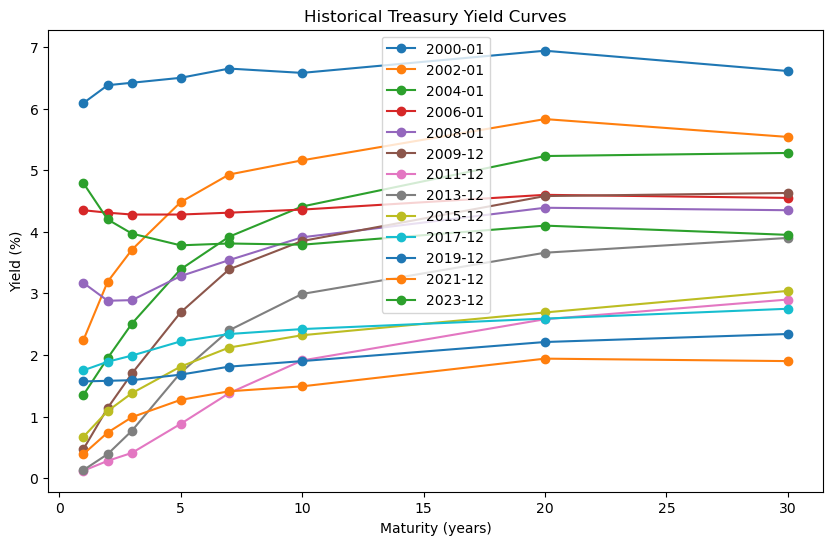

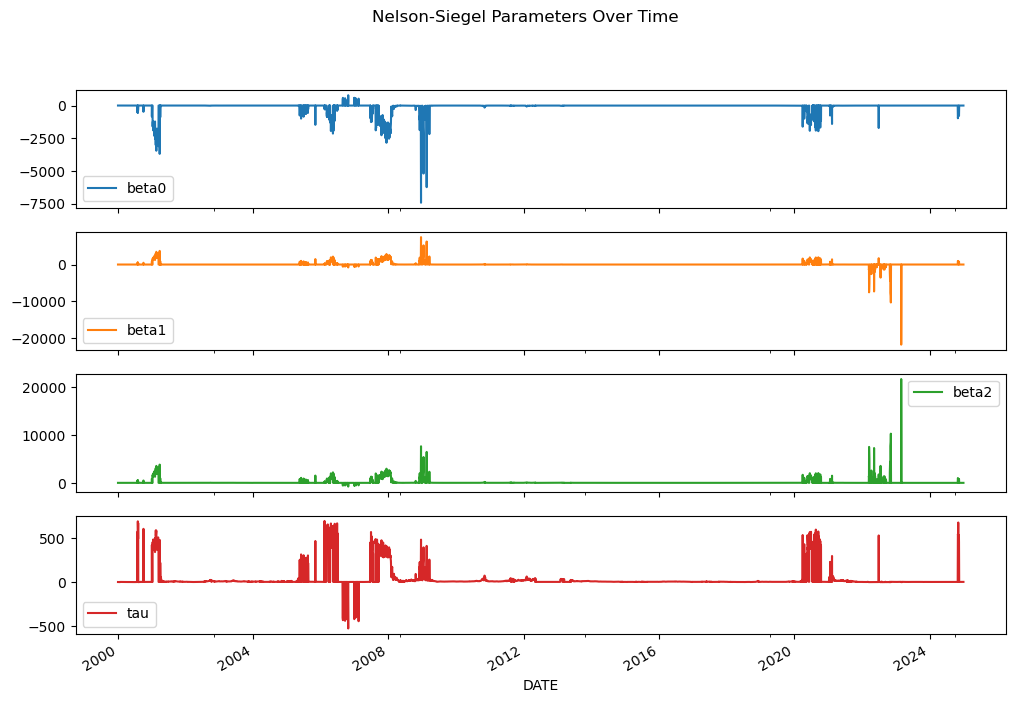


========== BUTTERFLY TRADE PERFORMANCE ==========
Total P&L: $441.00
Annualized Return: 0.18%
Annualized Volatility: 0.18%
Sharpe Ratio: 0.99


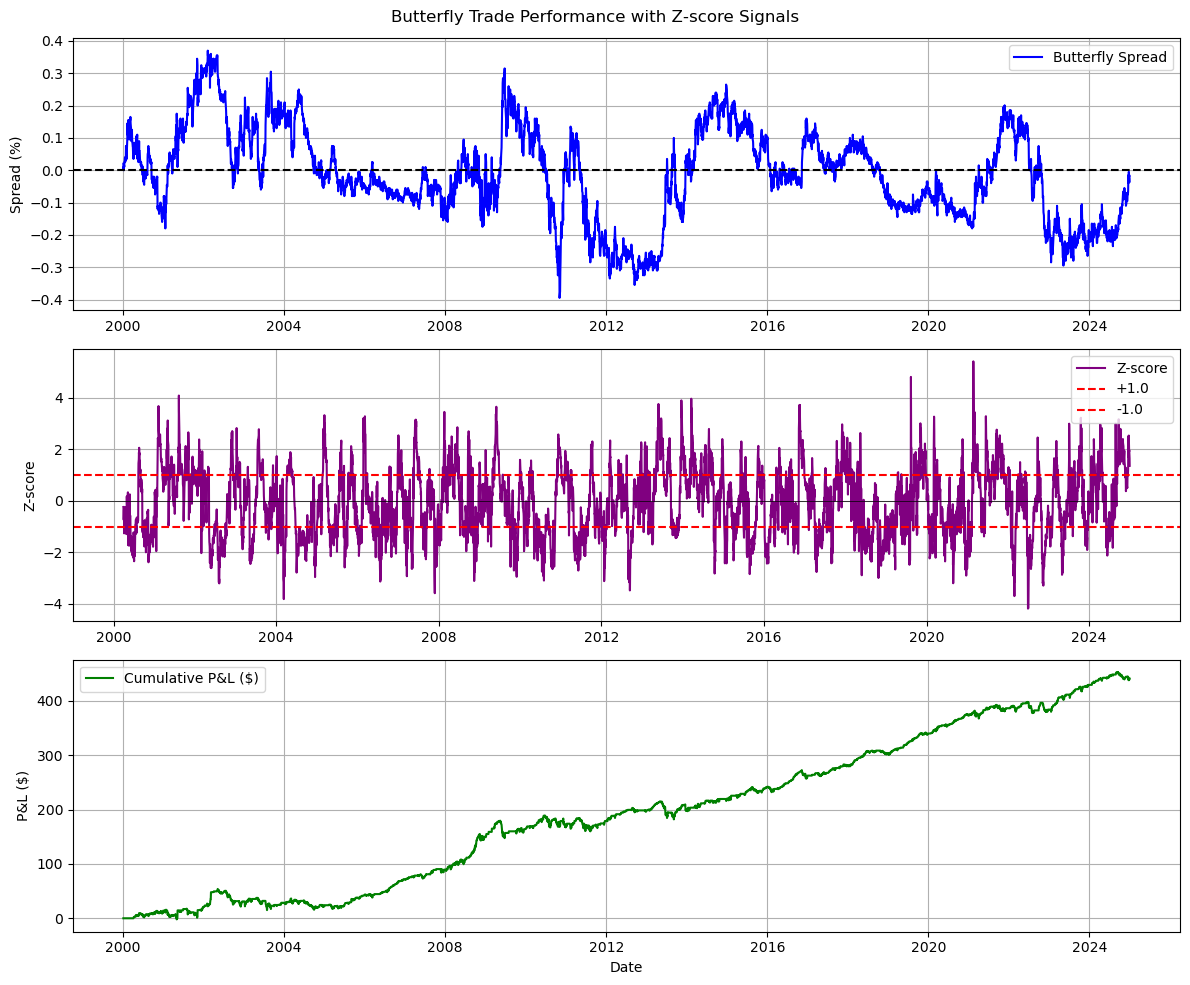

In [32]:
# ============================================================
# 6. BACKTEST BUTTERFLY TRADE
# ============================================================
# We assume a fixed capital of $10,000 per trade.
capital = 10000

# For simplicity, we treat the butterfly spread as a "price" in basis points.
# A 1 basis point change in the spread corresponds to a P&L of $1 per $10,000 notional? Actually,
# for a duration‑neutral butterfly, the DV01 (dollar value of 1bp) is roughly constant.
# We'll assume a DV01 of $100 per bp for the entire trade (i.e., $10,000 notional gives $1 per bp).
# So factor = 100 (dollars per 1% change in spread) but our spread is in percent, so 1% = 100bp.
# To keep it simple, we'll set factor = 100, meaning a 1% change in spread (100bp) gives $100 P&L.
# That is reasonable for a $10,000 trade.

factor = 100   # dollars per 1% change in butterfly spread

# Generate signals (same as before)
window = 60
butterfly_mean = butterfly.rolling(window).mean()
butterfly_std = butterfly.rolling(window).std()
butterfly_z = (butterfly - butterfly_mean) / butterfly_std

entry_threshold = 1.0
signals = pd.Series(0, index=butterfly.index)
signals[butterfly_z > entry_threshold] = -1   # sell butterfly (expect spread to decrease)
signals[butterfly_z < -entry_threshold] = 1    # buy butterfly (expect spread to increase)

# Shift signals to avoid look‑ahead (use yesterday's signal for today's trade)
signals_shifted = signals.shift(1).fillna(0)

# Correct P&L: for long (signal=+1), profit = + Δspread * factor
#            for short (signal=-1), profit = - Δspread * factor
# So profit = signals_shifted * butterfly.diff() * factor
pnl = signals_shifted * butterfly.diff() * factor
pnl = pnl.fillna(0)

# Cumulative P&L
cum_pnl = pnl.cumsum()

# Daily returns relative to capital
daily_returns = pnl / capital

# ============================================================
# Plot yield curve at selected dates
fig, ax = plt.subplots(figsize=(10,6))
for date in yields.index[::500]:  # every 500 days
    ax.plot(maturities, yields.loc[date].values, marker='o', label=date.strftime('%Y-%m'))
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Historical Treasury Yield Curves')
ax.legend()
plt.show()

# Plot Nelson‑Siegel parameters
params.plot(subplots=True, figsize=(12,8))
plt.suptitle('Nelson‑Siegel Parameters Over Time')
plt.show()

# Annualized performance
total_return = cum_pnl.iloc[-1]
annualized_return = (1 + daily_returns.mean()) ** 252 - 1   # compounded annual return
annualized_vol = daily_returns.std() * np.sqrt(252)
sharpe = annualized_return / annualized_vol if annualized_vol != 0 else 0

print("\n========== BUTTERFLY TRADE PERFORMANCE ==========")
print(f"Total P&L: ${total_return:,.2f}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")


# Plot with three subplots: Spread, Z‑score, Cumulative P&L
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10))

# Top: Butterfly spread
ax1.plot(butterfly.index, butterfly, label='Butterfly Spread', color='blue')
ax1.axhline(y=0, color='black', linestyle='--')
ax1.set_ylabel('Spread (%)')
ax1.legend()
ax1.grid(True)

# Middle: Z‑score with entry thresholds
ax2.plot(butterfly_z.index, butterfly_z, label='Z‑score', color='purple')
ax2.axhline(y=entry_threshold, color='red', linestyle='--', label=f'+{entry_threshold}')
ax2.axhline(y=-entry_threshold, color='red', linestyle='--', label=f'-{entry_threshold}')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('Z‑score')
ax2.legend()
ax2.grid(True)

# Bottom: Cumulative P&L
ax3.plot(cum_pnl.index, cum_pnl, label='Cumulative P&L ($)', color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('P&L ($)')
ax3.legend()
ax3.grid(True)

plt.suptitle('Butterfly Trade Performance with Z‑score Signals')
plt.tight_layout()
plt.show()